## Module 4: Cancer

## Team Members:
Roy Chen

Theresa Breckley

### Apoptosis-Related Gene Expression Patterns in Breast Cancer and Their Relationship to Tumor Stage




## Project Goal:
The goal of this project is to investigate whether apoptosis-related gene expression patterns can distinguish subgroups of breast cancer tumors and determine whether these patterns are predictive of tumor stage



## Disease Background:

Breast cancer is one of the most commonly diagnosed cancers worldwide and the most frequently diagnosed cancer among women. It arises from abnormal cell growth in breast tissue, most commonly in the epithelial cells lining the milk ducts or lobules.
Breast cancer is a heterogeneous disease, meaning it consists of multiple subtypes with distinct molecular and clinical characteristics. These subtypes are often classified based on receptor expression:
* Hormone receptor–positive (HR+): expresses estrogen (ER) and/or progesterone (PR) receptors
* HER2-positive: overexpression of the HER2 protein promotes aggressive growth
* Triple-negative breast cancer (TNBC): lacks ER, PR, and HER2 expression and is often more aggressive with fewer targeted treatment options



Apoptosis is a programmed cell death process that removes damaged, or unnecessary cells to maintain healthy tissue function. In normal cells, apoptosis is tightly regulated through cell cycle checkpoints, particularly at the G1, G2, and G0 phases, which act as check points to detect any abnormalities in cell reproduction.

At the G1 checkpoint, cells assess DNA integrity before replication. If any damage is detected, the tumor suppressor protein p53 can pause the cell cycle to allow repair or trigger apoptosis. The G2 checkpoint serves as a second control point after DNA replication, ensuring that genetic material has been accurately copied; cells with unrepaired damage are triggered to undergo apoptosis. In contrast, the G0 phase represents a resting state where cells exit the cycle to prevent unnecessary division, helping maintain tissue stability.

Cancer cells acquire the ability to resist apoptosis by disrupting these checkpoints. Mutations in key regulatory genes, such as TP53, allow cells with damaged DNA to bypass G1 and G2 control mechanisms and continue dividing uncontrollably.

Mutations in TP53 are common in aggressive forms of breast cancer, particularly triple-negative breast cancer. Loss of p53 function prevents damaged cells from undergoing apoptosis, allowing them to survive and accumulate additional mutations.
Additionally, many breast cancers exhibit overexpression of BCL-2, which inhibits apoptosis by blocking mitochondrial pathways of cell death. This imbalance between pro-apoptotic and anti-apoptotic signaling allows cancer cells to evade normal death mechanisms.
Disruption of apoptosis also contributes to treatment resistance, as therapies like chemotherapy and radiation rely on activating apoptotic pathways to kill cancer cells





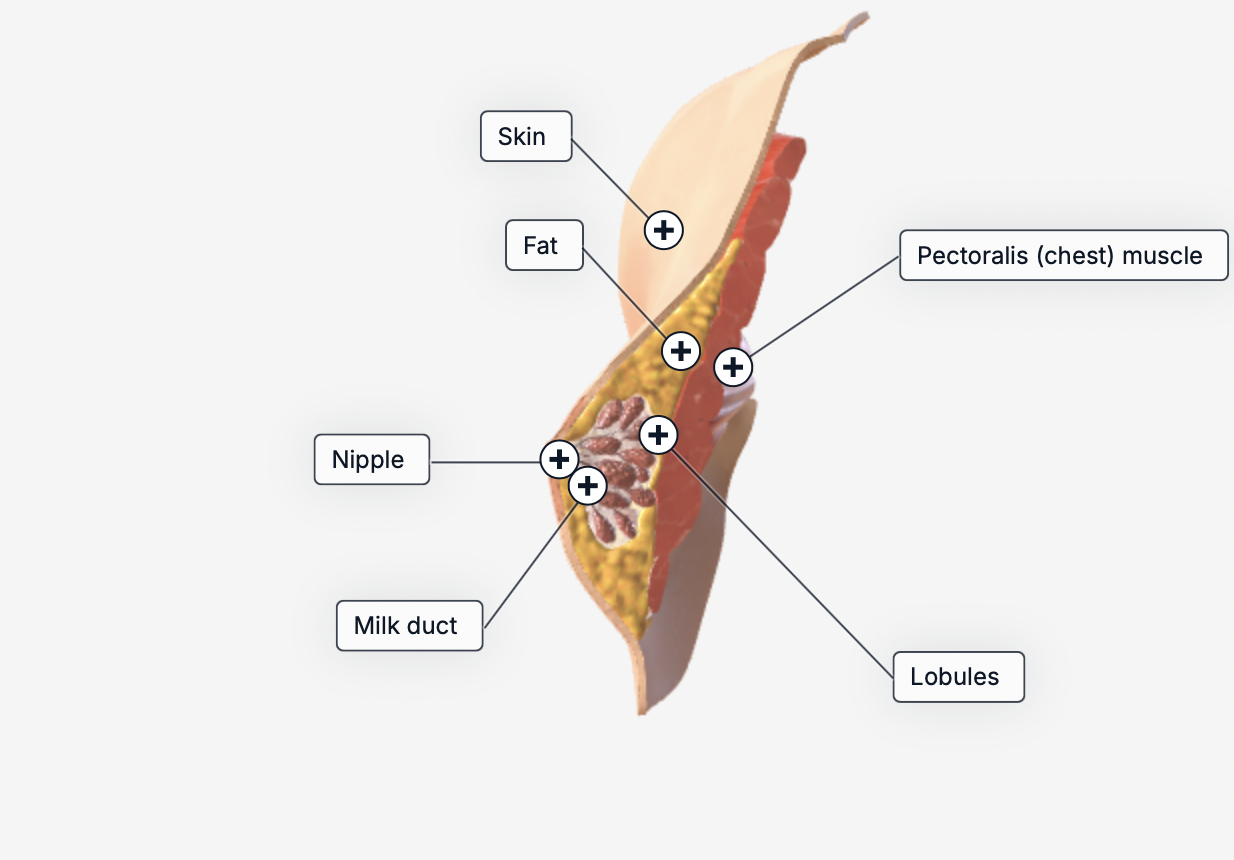

Anatomy of the breast showing ducts and lobules, where most breast cancers originate 
(Image provided by Susan G Komen)

## Prevalence, Risk Factors, and Treatment

Cancer is one of the leading causes of death worldwide and a major public health concern. In the United States, the most commonly diagnosed cancers include breast, prostate, lung, and colorectal cancer with lung cancer in the highest mortality rate due to its aggressive progression and late-stage detection.


Breast cancer is one of the most commonly diagnosed cancers worldwide and the most frequently diagnosed cancer among women. In the United States, it is also a leading cause of cancer-related death, although survival rates have improved significantly due to early detection and advances in treatment. 

Cancer incidence increases significantly with age, as mutations accumulate over time. Globally, cancer rates are rising due to population aging, environmental exposures, and lifestyle factors.


## Risk Factors:
Cancer risk can a rise from a combination factors such as genetic, environmental, and lifestyle factors. mutations in tumor suppressor genes like P53 and oncogenes, which increase susceptibility to cancer by disrupting normal cell cycle regulation and apoptosis can increase the chance of recieving cancer.

 While lifestyle factors like smoking, poor diet, physical inactivity, alcohol consumption, and exposure to UV radiation and air pollution are major contributors to cancer development.

People in more underdeveloped regions often have a higher cancer rate compare to more developed regions do due lack of access to health care, early screening and limited access to preventive care and treatment often experience higher mortality rates.

## Standard of Care Treatments
Current standard cancer treatments includes: 

* Surgery removes localized tumors
* Chemotherapy targets rapidly dividing cellss by inducing damage to the DNA
* Radiation therapy damages DNA in cancer cells to trigger apotosis
* Targeted therapy focuses on target certain cell
* Immunotherapy enhances the immune system’s ability to recognize and target cancer cells
* Apoptosis is controlled by a balance between pro apoptotic and anti apoptotic signals, Pro apoptotic (e.g., BAX, BAK) promote cell death while Anti apoptotic (BCL-2) prevent apoptosis.

In cancer, these pathways are often disrupted for example the loss of TP53 function prevents apoptosis while an overexpression of BCL-2 blocks cell death, allowing abnormal cells to survive. These changes enable cancer cells to evade death signals, continue proliferating, and resist therapies that rely on apoptosis.


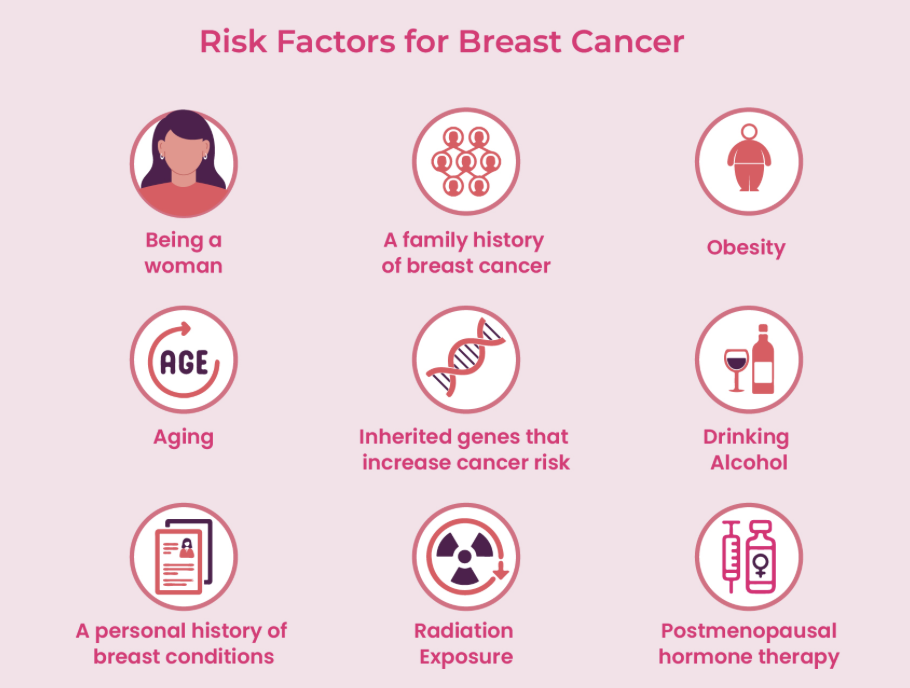

risk factors contributing to cancer development
(Image by drsanjaysharmacancer.com)

## Data-Set: 

The dataset used in this project is derived from The Cancer Genome Atlas (TCGA) and includes RNA sequencing (RNA-seq) data along with clinical metadata. For this analysis, we will focus on the training dataset.

The gene expression data (TRAINING_SET_GSE62944_subsample_log2TPM.csv) is organized as a matrix of genes × samples, where each value represents the expression level of a gene in a tumor sample. These values are given as log₂(TPM + 1), where TPM (Transcripts Per Million) normalizes for gene length and sequencing depth.

The metadata file (TRAINING_SET_GSE62944_metadata.csv) contains clinical information for each sample, including cancer type, tumor stage, and other patient characteristics.

By combining gene expression data with metadata, we can analyze how apoptosis-related gene expression varies across breast cancer samples and how it relates to tumor progression and clinical outcomes.

The genes selected for this analysis are associated with apoptosis pathways. These include:

TP53 (tumor suppressor gene involved in DNA damage response)
BAX (pro-apoptotic regulator that promotes cell death)
BCL2 (anti-apoptotic protein that inhibits cell death)
CASP3 (caspase involved in execution of apoptosis)
These genes were chosen because they play key roles in regulating programmed cell death and are commonly dysregulated in breast cancer.


In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_theme(style="whitegrid")


Training Data

The expression matrix is organized as genes × samples, while the metadata is organized as samples × clinical features.

In [12]:
# Load metadata and expression data

data = pd.read_csv('/Users/roychen/Desktop/Comp BME/Module-4-Cancer_breckley_chen/data/TRAINING_SET_GSE62944_subsample_log2TPM.csv', index_col=0)
    
metadata_df = pd.read_csv('/Users/roychen/Desktop/Comp BME/Module-4-Cancer_breckley_chen/data/TRAINING_SET_GSE62944_metadata.csv', index_col=0)
    

print("Expression data shape (genes x samples):", data.shape)
print("Metadata shape (samples x features):", metadata_df.shape)
print("\nMetadata columns:")
print(metadata_df.columns.tolist())

Expression data shape (genes x samples): (15716, 1802)
Metadata shape (samples x features): (1802, 29)

Metadata columns:
['cancer_type', 'bcr_patient_barcode', 'gender', 'race', 'ethnicity', 'age_at_diagnosis', 'ajcc_pathologic_tumor_stage', 'ajcc_nodes_pathologic_pn', 'ajcc_metastasis_pathologic_pm', 'ajcc_tumor_pathologic_pt', 'tumor_status', 'histologic_diagnosis', 'history_other_malignancy', 'history_thyroid_disease', 'history_thyroid_disease_other', 'history_reflux_disease_indicator', 'history_hormonal_contraceptives_use', 'pregnancies_count_miscarriage', 'jewish_religion_heritage_indicator', 'tobacco_smoking_age_started', 'family_history_cancer_type', 'OS', 'OS.time', 'DSS', 'DSS.time', 'DFI', 'DFI.time', 'PFI', 'PFI.time']


## Data Analysis: 

### Methods
The machine learning technique I am using is: *fill in and describe*

*What is this method optimizing? How does the model decide it is "good enough"?*

**

### Analysis
*(Describe how you analyzed the data. This is where you should intersperse your Python code so that anyone reading this can run your code to perform the analysis that you did, generate your figures, etc.)*

## Subset to Breast Cancer (BRCA) and Apoptosis Genes

To keep the project focused, we subset the dataset to breast cancer samples and to a hallmark-specific apoptosis gene set.

This gene list includes both pro-apoptotic and anti-apoptotic regulators, caspases, and key pathway members that are biologically relevant to cancer cells resisting programmed cell death.

In [13]:

# Subset metadata to breast cancer
brca_metadata = metadata_df[metadata_df["cancer_type"] == "BRCA"].copy()
print("BRCA metadata shape:", brca_metadata.shape)

# Apoptosis / resisting apoptosis gene set
desired_gene_list = [
    "BCL2", "BCL2L1", "MCL1", "BAX", "BAK1",
    "TP53", "CASP3", "CASP8", "CASP9",
    "FAS", "FADD", "XIAP", "BIRC5",
    "BAD", "BID", "BBC3", "PMAIP1"
]

available_genes = [gene for gene in desired_gene_list if gene in data.index]
missing_genes = [gene for gene in desired_gene_list if gene not in data.index]

print("Number of requested genes:", len(desired_gene_list))
print("Number of genes found in dataset:", len(available_genes))
print("Genes found:", available_genes)
print("Missing genes:", missing_genes)

# Subset expression data to BRCA samples and apoptosis genes
brca_sample_ids = brca_metadata.index.intersection(data.columns)
brca_data = data.loc[available_genes, brca_sample_ids]

print("\nBRCA expression subset shape (genes x BRCA samples):", brca_data.shape)
brca_data.head()

BRCA metadata shape: (80, 29)
Number of requested genes: 17
Number of genes found in dataset: 17
Genes found: ['BCL2', 'BCL2L1', 'MCL1', 'BAX', 'BAK1', 'TP53', 'CASP3', 'CASP8', 'CASP9', 'FAS', 'FADD', 'XIAP', 'BIRC5', 'BAD', 'BID', 'BBC3', 'PMAIP1']
Missing genes: []

BRCA expression subset shape (genes x BRCA samples): (17, 80)


,TCGA-E9-A1NI-01A-11R-A14D-07,TCGA-E2-A1LK-01A-21R-A14D-07,TCGA-BH-A0B2-01A-11R-A10J-07,TCGA-E2-A107-01A-11R-A10J-07,TCGA-LL-A5YN-01A-11R-A28M-07,TCGA-BH-A0DQ-01A-11R-A084-07,TCGA-D8-A73X-01A-11R-A32P-07,TCGA-AR-A0TP-01A-11R-A084-07,TCGA-E2-A1IF-01A-11R-A144-07,TCGA-EW-A6SD-01A-12R-A33J-07,...,TCGA-D8-A1JA-01A-11R-A13Q-07,TCGA-A2-A0D0-01A-11R-A00Z-07,TCGA-A8-A07B-01A-11R-A00Z-07,TCGA-C8-A275-01A-21R-A16F-07,TCGA-AO-A1KQ-01A-11R-A13Q-07,TCGA-E9-A5UP-01A-11R-A28M-07,TCGA-AR-A24T-01A-11R-A169-07,TCGA-D8-A1XB-01A-11R-A14D-07,TCGA-E9-A245-01A-22R-A16F-07,TCGA-WT-AB44-01A-11R-A41B-07
BCL2,5.248282,0.985832,5.784362,4.152444,3.692885,4.763121,5.221591,5.376440,4.050835,1.936183,...,1.693603,1.996426,5.779014,2.672941,5.405569,5.532695,5.958578,6.085538,6.243730,1.873949
BCL2L1,7.818040,6.874837,7.115444,7.566785,6.954511,7.408560,7.460900,6.024670,6.833883,7.256705,...,7.514368,6.689359,6.784440,7.055031,7.299693,8.759745,7.486974,7.529951,6.777458,6.381661
MCL1,7.816182,8.140580,8.165650,8.071209,7.278051,8.035222,8.193623,7.856121,8.412290,8.395989,...,9.078687,8.175704,8.279657,8.363384,7.513230,8.424985,8.756147,8.547165,7.503071,8.404597
BAX,6.720700,7.189939,6.504814,7.466535,7.662465,6.634294,6.585344,5.994697,7.414525,6.308539,...,5.301869,6.917972,6.257364,6.167569,7.180470,7.320232,5.802379,6.468790,5.992391,6.350984
BAK1,4.584133,5.334564,4.855286,4.845804,5.442022,5.610309,4.346540,4.705020,4.831672,4.301206,...,4.254277,5.583720,4.708609,5.048889,4.169633,4.340381,4.749268,4.740960,3.371286,3.386362


### Clean Key Metadata Fields

Our future supervised learning target will be tumor stage.
The metadata column that stores stage is:

#### ajcc_pathologic_tumor_stage

To make the eventual classification problem cleaner, we convert the original stage labels into a simpler binary grouping:

* Early stage   = Stage I or Stage II 
* Late stage = Stage III or Stage IV


In [14]:
# Keep only metadata rows that match the expression matrix
brca_metadata = brca_metadata.loc[brca_sample_ids].copy()

# Make age numeric for cleaner summaries
brca_metadata["age_at_diagnosis"] = pd.to_numeric(
    brca_metadata["age_at_diagnosis"], errors="coerce"
)

# Inspect tumor stage values
print(brca_metadata["ajcc_pathologic_tumor_stage"].value_counts(dropna=False))

def simplify_stage(stage_value):
    if pd.isna(stage_value):
        return np.nan
    stage_str = str(stage_value).upper()
    if "STAGE I" in stage_str or stage_str.startswith("I"):
        return "Early"
    if "STAGE II" in stage_str or stage_str.startswith("II"):
        return "Early"
    if "STAGE III" in stage_str or stage_str.startswith("III"):
        return "Late"
    if "STAGE IV" in stage_str or stage_str.startswith("IV"):
        return "Late"
    return np.nan

brca_metadata["stage_group"] = brca_metadata["ajcc_pathologic_tumor_stage"].apply(simplify_stage)

print("\nStage group counts:")
print(brca_metadata["stage_group"].value_counts(dropna=False))

print("\nAge summary:")
print(brca_metadata["age_at_diagnosis"].describe())

ajcc_pathologic_tumor_stage
Stage IIA          23
Stage IIB          14
Stage IIIA         11
Stage I             7
Stage IA            7
Stage IIIC          5
NaN                 4
Stage IV            4
Stage IIIB          3
Stage IB            1
[Not Available]     1
Name: count, dtype: int64

Stage group counts:
stage_group
Early    75
NaN       5
Name: count, dtype: int64

Age summary:
count    76.000000
mean     59.078947
std      12.609798
min      36.000000
25%      48.750000
50%      58.500000
75%      69.250000
max      84.000000
Name: age_at_diagnosis, dtype: float64


## Prepare the Matrix for PCA

Scikit-learn expects the matrix as samples × features, so we transpose the expression data and standardize the gene expression values before PCA.



In [15]:
# Transpose so rows = samples and columns = genes
X = brca_data.T

# Standardize the expression values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"], index=X.index)
pca_df = pca_df.join(brca_metadata)

# Add one key gene for coloring
if "BCL2" in X.columns:
    pca_df["BCL2_expression"] = X["BCL2"]

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)
pca_df.head()

Explained variance ratio:
[0.1987766  0.15712808]


,PC1,PC2,cancer_type,bcr_patient_barcode,gender,race,ethnicity,age_at_diagnosis,ajcc_pathologic_tumor_stage,ajcc_nodes_pathologic_pn,...,OS,OS.time,DSS,DSS.time,DFI,DFI.time,PFI,PFI.time,stage_group,BCL2_expression
TCGA-E9-A1NI-01A-11R-A14D-07,-0.246504,0.978967,BRCA,TCGA-E9-A1NI,FEMALE,WHITE,NOT HISPANIC OR LATINO,51.0,Stage IIA,N0,...,0.0,300.0,0.0,300.0,0.0,300.0,0.0,300.0,Early,5.248282
TCGA-E2-A1LK-01A-21R-A14D-07,-5.239930,-1.590538,BRCA,TCGA-E2-A1LK,FEMALE,BLACK OR AFRICAN AMERICAN,NOT HISPANIC OR LATINO,84.0,Stage IIIC,N3a,...,1.0,266.0,1.0,266.0,1.0,155.0,1.0,155.0,Early,0.985832
TCGA-BH-A0B2-01A-11R-A10J-07,0.263982,-0.156312,BRCA,TCGA-BH-A0B2,FEMALE,WHITE,NOT HISPANIC OR LATINO,43.0,Stage I,N0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Early,5.784362
TCGA-E2-A107-01A-11R-A10J-07,-1.693936,1.653981,BRCA,TCGA-E2-A107,FEMALE,WHITE,NOT HISPANIC OR LATINO,54.0,Stage IIIA,N2a,...,0.0,1047.0,0.0,1047.0,0.0,1047.0,0.0,1047.0,Early,4.152444
TCGA-LL-A5YN-01A-11R-A28M-07,-3.004212,1.201851,BRCA,TCGA-LL-A5YN,FEMALE,BLACK OR AFRICAN AMERICAN,NOT HISPANIC OR LATINO,46.0,Stage IIA,N0 (i-),...,0.0,447.0,0.0,447.0,0.0,447.0,0.0,447.0,Early,3.692885


## PCA Visualization

The first PCA plot is colored by umor stage group  to see whether apoptosis-related expression patterns separate earlier vs later tumors.

The second PCA plot is colored by BCL2 expression, since BCL2 is a major anti-apoptotic gene and a biologically meaningful marker for this hallmark.

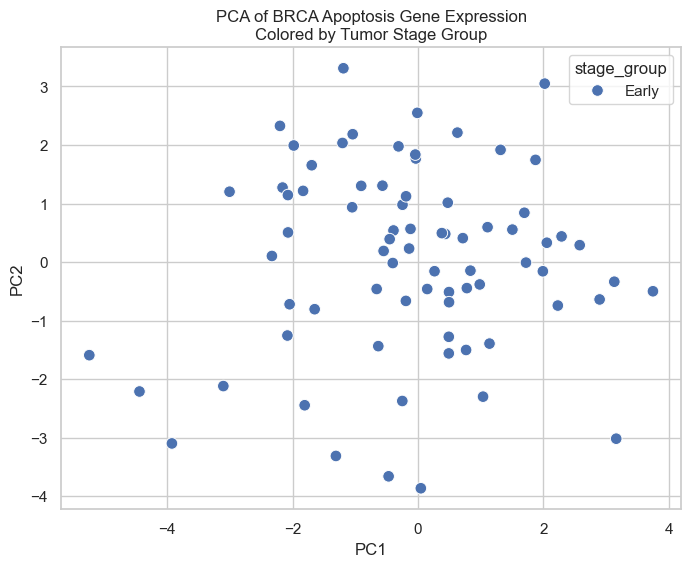

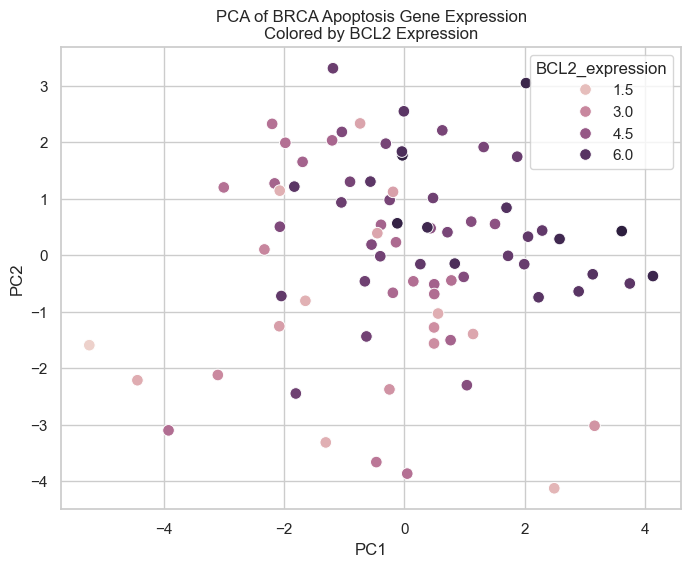

In [16]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="stage_group",
    s=70
)
plt.title("PCA of BRCA Apoptosis Gene Expression\nColored by Tumor Stage Group")
plt.show()

if "BCL2_expression" in pca_df.columns:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=pca_df,
        x="PC1",
        y="PC2",
        hue="BCL2_expression",
        s=70
    )
    plt.title("PCA of BRCA Apoptosis Gene Expression\nColored by BCL2 Expression")
    plt.show()


## PCA Interpretation:

These PCA plots help us visualize whether breast cancer tumors vary in apoptosis-related expression in a structured way.
If samples separate by stage group or by BCL2 expression, that suggests apoptosis signaling may be associated with disease progression or tumor subtype differences in BRCA.

## K-means Clustering

For the second required unsupervised step, we use K-means clustering on the apoptosis gene expression matrix.

This is a simple first clustering method that can reveal whether there are distinct subgroups of BRCA tumors based on apoptosis-related gene expression patterns.

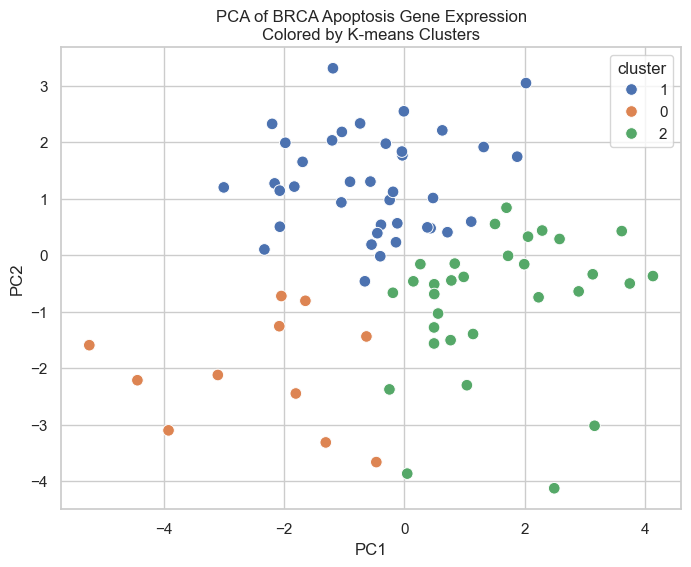

Cluster counts:
cluster
1    38
2    31
0    11
Name: count, dtype: int64


In [17]:
# K-means clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

pca_df["cluster"] = clusters.astype(str)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    s=70
)
plt.title("PCA of BRCA Apoptosis Gene Expression\nColored by K-means Clusters")
plt.show()

print("Cluster counts:")
print(pca_df["cluster"].value_counts())

## Clustering Interpretation

K-means clustering groups tumors with similar apoptosis-related expression patterns.
If the clusters appear visually separated on the PCA plot, that suggests the tumors may contain biologically meaningful subgroups.


In later work, we can compare these clusters to stage or other metadata variables to understand what the clusters may represent

## Verify and validate your analysis: 
*Pick a SPECIFIC metric to determine how well your model is performing and describe how it works here.*

*(Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., a published paper).*

## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## NOTES FROM YOUR TEAM: 
*This is where our team is taking notes and recording activity.*

## QUESTIONS FOR YOUR TA: 
*These are questions we have for our TA.*